In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [61]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np

In [62]:
base_path = "../data/preprocessed/processed_data.xlsx"
df=pd.read_excel(base_path)

In [63]:
# frequency hourly
df.set_index('Date',inplace=True)
df = df.asfreq('h')

# Resample hourly

In [64]:
hourly_data=df.copy()
hourly_data=hourly_data.resample('h').mean()
hourly_data['Low Carbon Percentage']=hourly_data['Low Carbon Percentage']/100
hourly_data['Renewable Percentage']=hourly_data['Renewable Percentage']/100

In [65]:
hourly_data.head()

,Carbon Intensity gCO₂eq/kWh (LCA),Carbon Intensity gCO₂eq/kWh (direct),Low Carbon Percentage,Renewable Percentage,End user energy consumtion(KWH),Total energy production Swiss controlblock(KWH),Total energy consumption Swiss controlblock(KWH),Grid feed-in Swiss transmission grid(KWH),Net outflow of the Swiss transmission grid(KWH)
Date,,,,,,,,,
2021-01-01 00:00:00,187.06,147.82,0.8025,0.3514,4.974473e+06,3598023.247,5.613422e+06,2.597755e+06,1.908120e+06
2021-01-01 01:00:00,199.85,159.56,0.7884,0.3317,6.536098e+06,4848098.313,7.504007e+06,3.495872e+06,2.508571e+06
2021-01-01 02:00:00,179.60,140.89,0.8034,0.3388,6.313985e+06,4729802.640,7.620990e+06,3.423373e+06,2.740640e+06
2021-01-01 03:00:00,159.06,122.40,0.8149,0.3038,6.056025e+06,4673477.453,7.577100e+06,3.359224e+06,2.765117e+06
2021-01-01 04:00:00,180.92,142.60,0.8002,0.3054,5.780124e+06,4547793.409,7.442931e+06,3.259018e+06,2.766044e+06


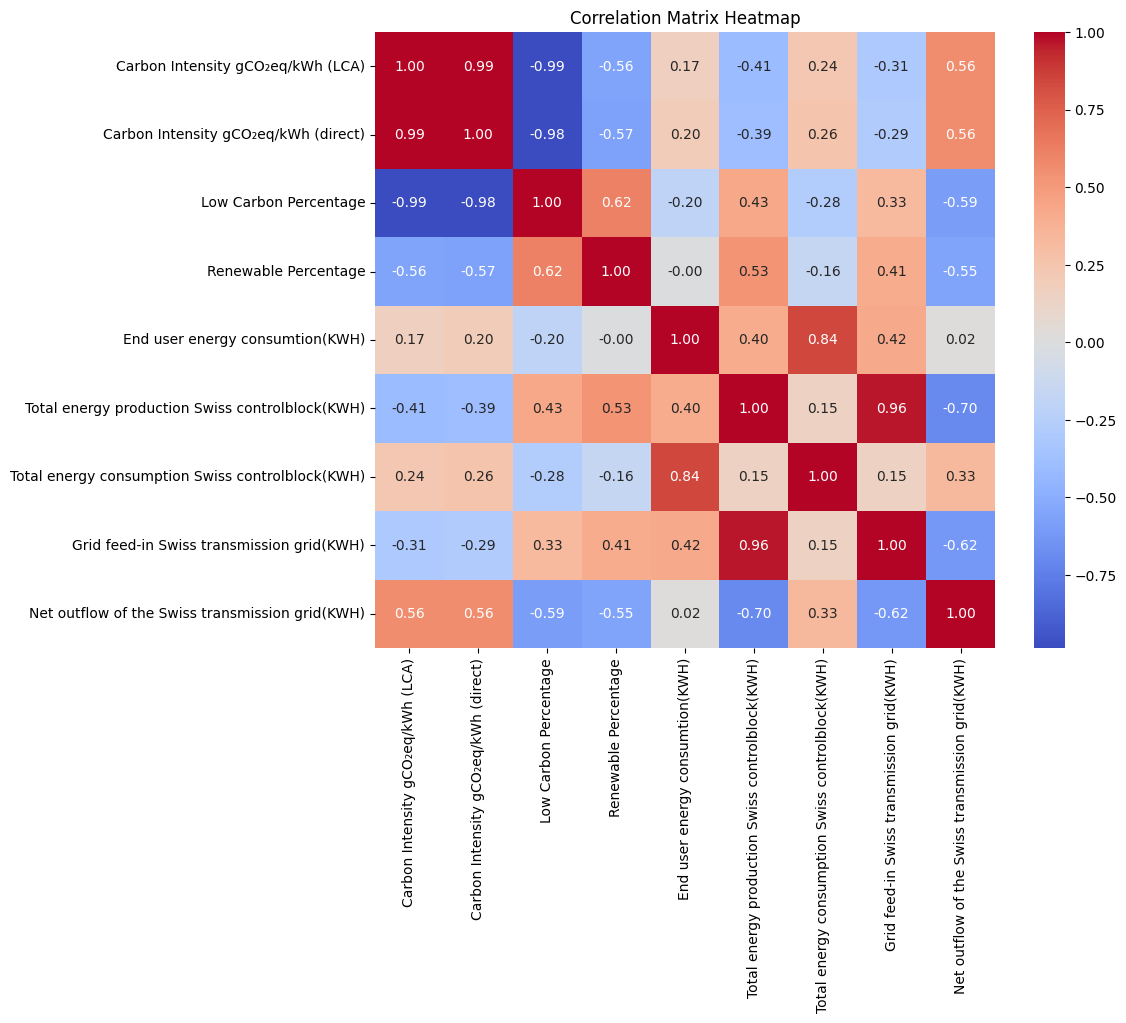

In [66]:
# Calculate the correlation matrix
correlation_matrix = hourly_data.corr()


# Create a heatmap for the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix Heatmap")
plt.show()


In [67]:
#split data

train_data=hourly_data['2021':'2022']
test_data=hourly_data['2023':]
#exogeneous variables
exog_train = train_data[[ 'Total energy production Swiss controlblock(KWH)',
                         'Total energy consumption Swiss controlblock(KWH)',
                         'Renewable Percentage',
                         'Low Carbon Percentage',
                         #'Grid feed-in Swiss transmission grid(KWH)',
                         #'Net outflow of the Swiss transmission grid(KWH)',
                         #'End user energy consumtion(KWH)'
                        ]]
exog_test = test_data[['Total energy production Swiss controlblock(KWH)',
                       'Total energy consumption Swiss controlblock(KWH)',
                       'Renewable Percentage',
                       'Low Carbon Percentage',
                       #'Grid feed-in Swiss transmission grid(KWH)',
                       #'Net outflow of the Swiss transmission grid(KWH)',
                       #'End user energy consumtion(KWH)'
                       ]]
#Target Variable
y_train = train_data['Carbon Intensity gCO₂eq/kWh (LCA)']  # Target variable for training
y_test = test_data['Carbon Intensity gCO₂eq/kWh (LCA)']

In [68]:

#define SARIMA parameters for monthly data
sarima_order_hourly=(0,0,1)
seasonal_order_hourly=(0,1,0,24)

#fit the model
sarima_hourly_model=SARIMAX(
    y_train,
    exog=exog_train,
    order=sarima_order_hourly,
    seasonal_order=seasonal_order_hourly,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=5000,method='powell' )


In [69]:
#predict
predict=sarima_hourly_model.forecast(steps=len(y_test),exog=exog_test)
predict_train=sarima_hourly_model.predict(start=y_train.index[0],end=y_train.index[-1])

## Metrics

In [70]:
#evaluate

mae=mean_absolute_error(y_test,predict)
mse=mean_squared_error(y_test,predict)
rmse=np.sqrt(mse)
mape=np.mean(np.abs(y_test-predict)/y_test) * 100

print("\nThe metrics for the Sarima model")
print()
print(f"mean absolute error :  {mae}")
print(f"mean squared error :  {mse}")
print(f"Root mean squared error :  {rmse}")

print(f"mean absolute percentage error :  {mape}")


The metrics for the Sarima model

mean absolute error :  5.963453291170394
mean squared error :  53.006467784366926
Root mean squared error :  7.280554084983294
mean absolute percentage error :  8.129931505924025


In [71]:
import os
exog_df=pd.DataFrame({'exogenous variables':exog_train.columns})
metrics_df=pd.DataFrame({'Metric': ['MAE', 'MSE'], 
                        'Value': [mae, mse]})
result=pd.concat([exog_df,metrics_df],axis=0)
output_file="exog_variables_metrics_hourly.csv"
if os.path.exists(output_file):
   
    result.to_csv(output_file, index=False, header=False, mode='a')
else:
    
    result.to_csv(output_file, index=False) 

result

,exogenous variables,Metric,Value
0,Total energy production Swiss controlblock(KWH),NaN,NaN
1,Total energy consumption Swiss controlblock(KWH),NaN,NaN
2,Renewable Percentage,NaN,NaN
3,Low Carbon Percentage,NaN,NaN
0,NaN,MAE,5.963453
1,NaN,MSE,53.006468


train data comparaison(check if there is overfitting)

Since the test data is result and the trained model result are similar, there is no overfitting

In [72]:
#evaluate

mae_train=mean_absolute_error(y_train,predict_train)
mse_train=mean_squared_error(y_train,predict_train)
rmse_train=np.sqrt(mse_train)
mape_train=np.mean(np.abs(y_train-predict_train)/y_train) * 100

print("\nThe metrics for the Sarima model")
print()
print(f"mean absolute error :  {mae_train}")
print(f"mean squared error :  {mse_train}")
print(f"Root mean squared error :  {rmse_train}")

print(f"mean absolute percentage error :  {mape_train}")


The metrics for the Sarima model

mean absolute error :  5.321351571110802
mean squared error :  1268.961256660962
Root mean squared error :  35.62248246067309
mean absolute percentage error :  4.260613987529182


## Residual

In [73]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Forecast': predict,
    'difference':abs(y_test-predict)
})
comparison

,Actual,Forecast,difference
2023-01-01 00:00:00,100.10,89.619162,10.480838
2023-01-01 01:00:00,97.58,85.767388,11.812612
2023-01-01 02:00:00,98.50,90.587792,7.912208
2023-01-01 03:00:00,105.55,97.612218,7.937782
2023-01-01 04:00:00,104.41,95.350750,9.059250
...,...,...,...
2023-12-31 19:00:00,46.49,45.284495,1.205505
2023-12-31 20:00:00,52.70,48.869358,3.830642
2023-12-31 21:00:00,66.89,62.154966,4.735034
2023-12-31 22:00:00,69.07,65.723021,3.346979


## Plot residual data

<Axes: >

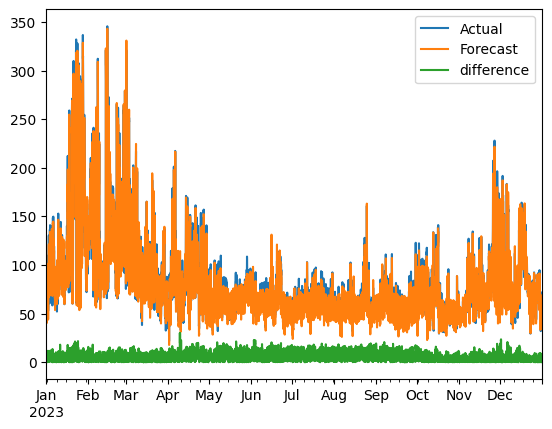

In [74]:
comparison.plot()

## Plot the Hourly without aggregation

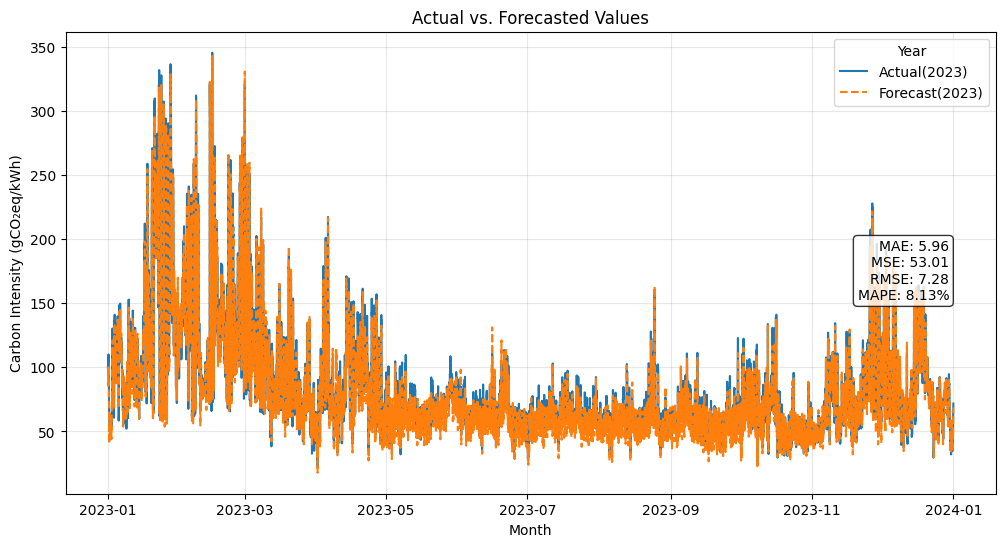

In [75]:


plt.figure(figsize=(12, 6))
plt.plot(y_test.index,y_test, label='Actual(2023)')
plt.plot(y_test.index,predict, label='Forecast(2023)', linestyle='--')
#title and label
plt.xlabel("Month")
plt.ylabel("Carbon Intensity (gCO₂eq/kWh)")
""" plt.xticks(range(1, 13), [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], fontsize=10) """
plt.legend(title="Year", fontsize=10)
plt.grid(alpha=0.3)
plt.title('Actual vs. Forecasted Values')

#metrics

metrics_text_predicted = (
    f"MAE: {mae:.2f}\n"
    f"MSE: {mse:.2f}\n"
    f"RMSE: {rmse:.2f}\n"
    f"MAPE: {mape:.2f}%"
)
plt.text(
    0.95, 0.55, metrics_text_predicted, transform=plt.gca().transAxes,
    fontsize=10, verticalalignment='top', horizontalalignment='right',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)
plt.show()


## Aggregate the predicted data to plot

In [76]:
#convert to series
predicted_series=pd.Series(predict)
#aggragate to daily predicted
daily_forecast=predicted_series.resample('D').mean()
weekly_forecast=predicted_series.resample('W').mean()
monthly_forecast=predicted_series.resample('ME').mean()
##test data
daily_test_data = y_test.resample('D').mean()
weekly_test_data=y_test.resample('W').mean()
monthly_test_data=y_test.resample('ME').mean()

metrics for the aggregated data

In [77]:
#daily
mae_daily=mean_absolute_error(daily_test_data,daily_forecast)
mse=mean_squared_error(daily_test_data,daily_forecast)
rmse=np.sqrt(mse)
mape=np.mean(np.abs(daily_test_data-daily_forecast)/daily_test_data) * 100
print("\nThe metrics for the Sarima model")
print()
print(f"mean absolute error :  {mae}")
print(f"mean squared error :  {mse}")
print(f"Root mean squared error :  {rmse}")

print(f"mean absolute percentage error :  {mape}")


The metrics for the Sarima model

mean absolute error :  5.963453291170394
mean squared error :  28.584823057355035
Root mean squared error :  5.346477630866422
mean absolute percentage error :  6.17302030786157


In [78]:
#weekly
mae_daily=mean_absolute_error(weekly_test_data,weekly_forecast)
mse=mean_squared_error(weekly_test_data,weekly_forecast)
rmse=np.sqrt(mse)
mape=np.mean(np.abs(weekly_test_data-weekly_forecast)/weekly_test_data) * 100
print("\nThe metrics for the Sarima model")
print()
print(f"mean absolute error :  {mae}")
print(f"mean squared error :  {mse}")
print(f"Root mean squared error :  {rmse}")

print(f"mean absolute percentage error :  {mape}")


The metrics for the Sarima model

mean absolute error :  5.963453291170394
mean squared error :  23.35781472019905
Root mean squared error :  4.8329923153465755
mean absolute percentage error :  5.68499143981676


In [79]:
#monthly
mae_daily=mean_absolute_error(monthly_test_data,monthly_forecast)
mse=mean_squared_error(monthly_test_data,monthly_forecast)
rmse=np.sqrt(mse)
mape=np.mean(np.abs(monthly_test_data-monthly_forecast)/monthly_test_data) * 100
print("\nThe metrics for the Sarima model")
print()
print(f"mean absolute error :  {mae}")
print(f"mean squared error :  {mse}")
print(f"Root mean squared error :  {rmse}")

print(f"mean absolute percentage error :  {mape}")


The metrics for the Sarima model

mean absolute error :  5.963453291170394
mean squared error :  21.34577246206887
Root mean squared error :  4.620148532468288
mean absolute percentage error :  5.609773684006188


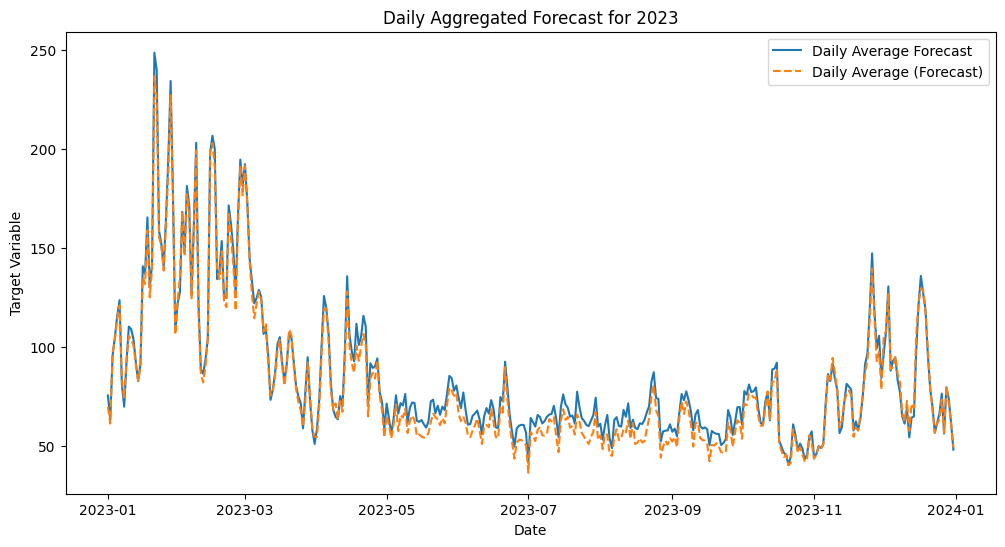

In [80]:
plt.figure(figsize=(12, 6))
plt.plot(daily_test_data.index, daily_test_data, label='Daily Average Forecast')
plt.plot(daily_forecast.index, daily_forecast, label='Daily Average (Forecast)',linestyle='--')
plt.title('Daily Aggregated Forecast for 2023')
plt.xlabel('Date')
plt.ylabel('Target Variable')
plt.legend()
plt.show()

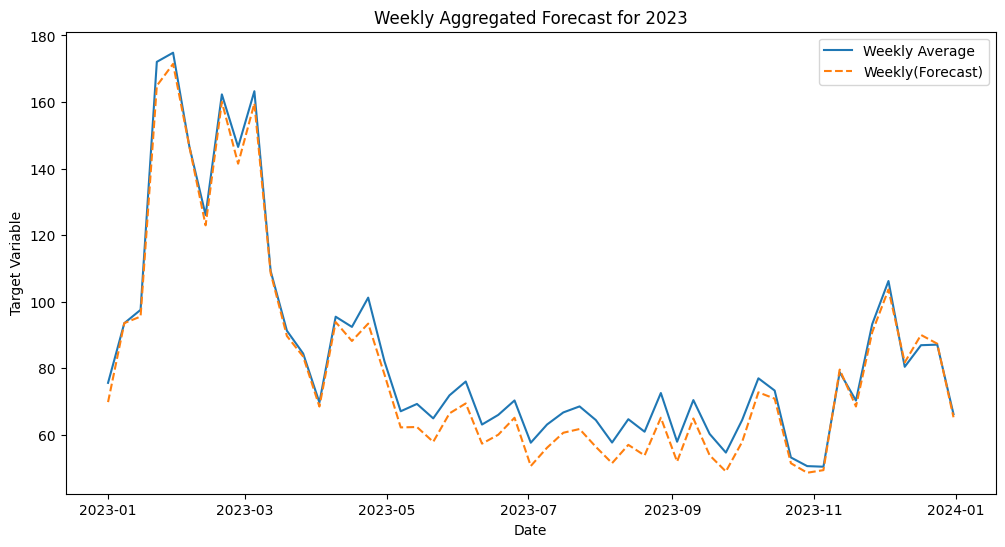

In [81]:
plt.figure(figsize=(12, 6))
plt.plot(weekly_test_data.index, weekly_test_data, label='Weekly Average ')
plt.plot(weekly_forecast.index, weekly_forecast, label='Weekly(Forecast)',linestyle='--')
plt.title('Weekly Aggregated Forecast for 2023')
plt.xlabel('Date')
plt.ylabel('Target Variable')
plt.legend()
plt.show()

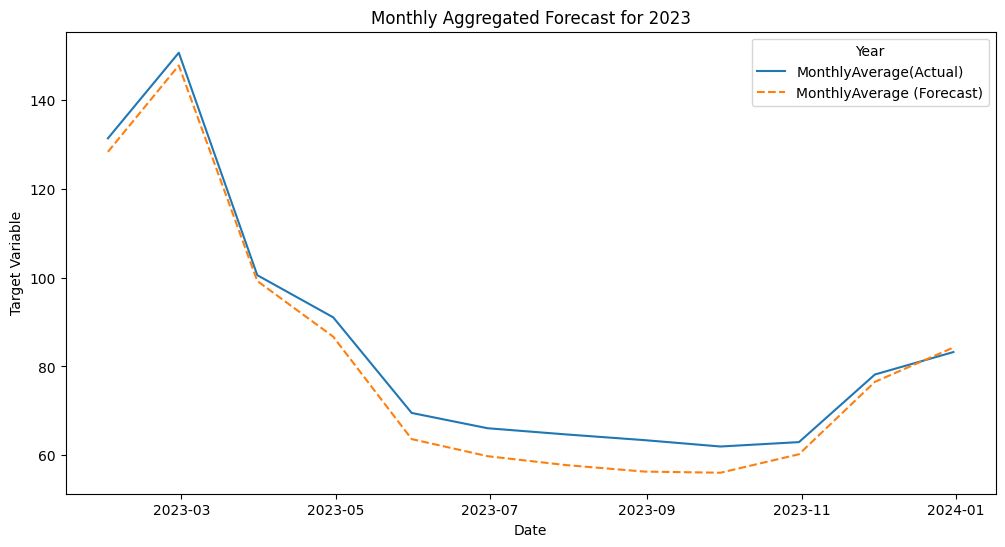

In [82]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_test_data.index,monthly_test_data, label='MonthlyAverage(Actual)')
plt.plot(monthly_forecast.index,monthly_forecast, label='MonthlyAverage (Forecast)',linestyle='--')
plt.title('Monthly Aggregated Forecast for 2023')
plt.xlabel('Date')
plt.ylabel('Target Variable')

plt.legend(title="Year", fontsize=10)

plt.title('Monthly Aggregated Forecast for 2023')
plt.show()

In [83]:
import os
exog_df=pd.DataFrame({'exogenous variables':exog_train.columns})
metrics_df=pd.DataFrame({'Metric': ['MAE', 'MSE'], 
                        'Value': [mae, mse]})
result=pd.concat([exog_df,metrics_df],axis=0)
output_file="exog_variables_metrics_hourly.csv"
if os.path.exists(output_file):
   
    result.to_csv(output_file, index=False, header=False, mode='a')
else:
    
    result.to_csv(output_file, index=False) 

result

,exogenous variables,Metric,Value
0,Total energy production Swiss controlblock(KWH),NaN,NaN
1,Total energy consumption Swiss controlblock(KWH),NaN,NaN
2,Renewable Percentage,NaN,NaN
3,Low Carbon Percentage,NaN,NaN
0,NaN,MAE,5.963453
1,NaN,MSE,21.345772


# Save the model and the test data for the app

In [84]:
## Save trained model
import joblib
joblib.dump(sarima_hourly_model,"../data/models/sarimax_model_hourly.pkl")
print("Trained model saved to sarimax_model.pkl")

' ## Save trained model\nimport joblib\njoblib.dump(sarima_hourly_model,"../data/models/sarimax_model_hourly.pkl")\nprint("Trained model saved to sarimax_model.pkl") '

In [85]:
#test data
y_test.to_csv("../data/test_data/test_data.csv",index=True)

#exogenoues variable
exog_test.to_csv("../data/test_data/exog_test_hourly.csv",index=True)

' #test data\ny_test.to_csv("../data/test_data/test_data.csv",index=True)\n\n#exogenoues variable\nexog_test.to_csv("../data/test_data/exog_test_hourly.csv",index=True) '